In [1]:
import os
import cv2
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Corrected import statement
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import TensorBoard
from sklearn.metrics import classification_report
from tensorflow.keras import layers, callbacks
import warnings
warnings.filterwarnings('ignore')

In [2]:
!git clone https://github.com/niaz1971/EYE_DISEASE_PREDICTION_SHU_CONFERENCE_PAPER.git

Cloning into 'EYE_DISEASE_PREDICTION_SHU_CONFERENCE_PAPER'...
remote: Enumerating objects: 93, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 93 (delta 26), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (93/93), 120.01 MiB | 15.68 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [3]:
!ls

EYE_DISEASE_PREDICTION_SHU_CONFERENCE_PAPER  sample_data


In [4]:
cd EYE_DISEASE_PREDICTION_SHU_CONFERENCE_PAPER/

/content/EYE_DISEASE_PREDICTION_SHU_CONFERENCE_PAPER


In [5]:
!ls

1_EYE_DISEASE__RESNET101_MODEL.ipynb
2_EYE_DISEASE__ConvNeXtTiny_MODEL.ipynb
3_EYE_DISEASE__XCEPTION_MODEL.ipynb
4_EYE_DISEASE__InceptionResNetV2_MODEL.ipynb
5_EYE_DISEASE__VGG19_MODEL.ipynb
6_EYE_DISEASE__ResNet50_MODEL.ipynb
7_EYE_DISEASE__DenseNet121_MODEL.ipynb
8_EYE_DISEASE__VGG16_MODEL.ipynb
DATASETLINK.txt
EYE_DISEASE__ConvNeXtTiny_MODEL.ipynb
EYE_DISEASE__DenseNet121_MODEL.ipynb
EYE_DISEASE__EfficientNetB7_MODEL.ipynb
EYE_DISEASE__InceptionResNetV2_MODEL.ipynb
EYE_DISEASE__MovileNetV2_MODEL.ipynb
EYE_DISEASE__ResNet50_MODEL.ipynb
EYE_DISEASE__VGG16_MODEL.ipynb
EYE_DISEASE__VGG19_MODEL.ipynb
EYE_DISEASE__XCEPTION_MODEL.ipynb
kaggle.json


In [6]:
!pip install lime kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=719b4e1c9228c86d2b2c71f5f56060ce2049d60f2557db6313154d358b1da1e2
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
100% 736M/736M [00:07<00:00, 98.1MB/s]



In [7]:
!ls

1_EYE_DISEASE__RESNET101_MODEL.ipynb
2_EYE_DISEASE__ConvNeXtTiny_MODEL.ipynb
3_EYE_DISEASE__XCEPTION_MODEL.ipynb
4_EYE_DISEASE__InceptionResNetV2_MODEL.ipynb
5_EYE_DISEASE__VGG19_MODEL.ipynb
6_EYE_DISEASE__ResNet50_MODEL.ipynb
7_EYE_DISEASE__DenseNet121_MODEL.ipynb
8_EYE_DISEASE__VGG16_MODEL.ipynb
DATASETLINK.txt
EYE_DISEASE__ConvNeXtTiny_MODEL.ipynb
EYE_DISEASE__DenseNet121_MODEL.ipynb
EYE_DISEASE__EfficientNetB7_MODEL.ipynb
EYE_DISEASE__InceptionResNetV2_MODEL.ipynb
EYE_DISEASE__MovileNetV2_MODEL.ipynb
EYE_DISEASE__ResNet50_MODEL.ipynb
eye-diseases-classification.zip
EYE_DISEASE__VGG16_MODEL.ipynb
EYE_DISEASE__VGG19_MODEL.ipynb
EYE_DISEASE__XCEPTION_MODEL.ipynb
kaggle.json


In [8]:
!unzip -q eye-diseases-classification.zip
!rm eye-diseases-classification.zip
!rm kaggle.json

In [9]:
!ls

1_EYE_DISEASE__RESNET101_MODEL.ipynb
2_EYE_DISEASE__ConvNeXtTiny_MODEL.ipynb
3_EYE_DISEASE__XCEPTION_MODEL.ipynb
4_EYE_DISEASE__InceptionResNetV2_MODEL.ipynb
5_EYE_DISEASE__VGG19_MODEL.ipynb
6_EYE_DISEASE__ResNet50_MODEL.ipynb
7_EYE_DISEASE__DenseNet121_MODEL.ipynb
8_EYE_DISEASE__VGG16_MODEL.ipynb
dataset
DATASETLINK.txt
EYE_DISEASE__ConvNeXtTiny_MODEL.ipynb
EYE_DISEASE__DenseNet121_MODEL.ipynb
EYE_DISEASE__EfficientNetB7_MODEL.ipynb
EYE_DISEASE__InceptionResNetV2_MODEL.ipynb
EYE_DISEASE__MovileNetV2_MODEL.ipynb
EYE_DISEASE__ResNet50_MODEL.ipynb
EYE_DISEASE__VGG16_MODEL.ipynb
EYE_DISEASE__VGG19_MODEL.ipynb
EYE_DISEASE__XCEPTION_MODEL.ipynb


In [10]:
# load dataset
train_dir = 'dataset'

# Load training dataset without preprocessing
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='training',
    batch_size=32,
    image_size=(256, 256),
    seed=123,
    shuffle=True,
)

# Load validation dataset without preprocessing
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    batch_size=32,
    image_size=(256, 256),
    seed=42,
)

Found 4217 files belonging to 4 classes.
Using 3374 files for training.
Found 4217 files belonging to 4 classes.
Using 843 files for validation.


In [11]:
# Get the class names from the subdirectories in the training directory
class_names = sorted(os.listdir(train_dir))

# Print the class names and the number of classes
print("Class Names:", class_names)
num_classes = len(class_names)
print("Number of Classes:", num_classes)

Class Names: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Number of Classes: 4


In [12]:
def visualize_images(path, target_size=(256, 256), num_images=5):

    # Get a list of image filenames
    image_filenames = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

    if not image_filenames:
        raise ValueError("No images found in the specified path")

    # Select random images
    selected_images = random.sample(image_filenames, min(num_images, len(image_filenames)))

    # Create a figure and axes
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3), facecolor='white')

    # Display each image
    for i, image_filename in enumerate(selected_images):
        # Load image and resize
        image_path = os.path.join(path, image_filename)
        image = Image.open(image_path)
        image = image.resize(target_size)

        # Display image
        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(image_filename)  # Set image filename as title

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


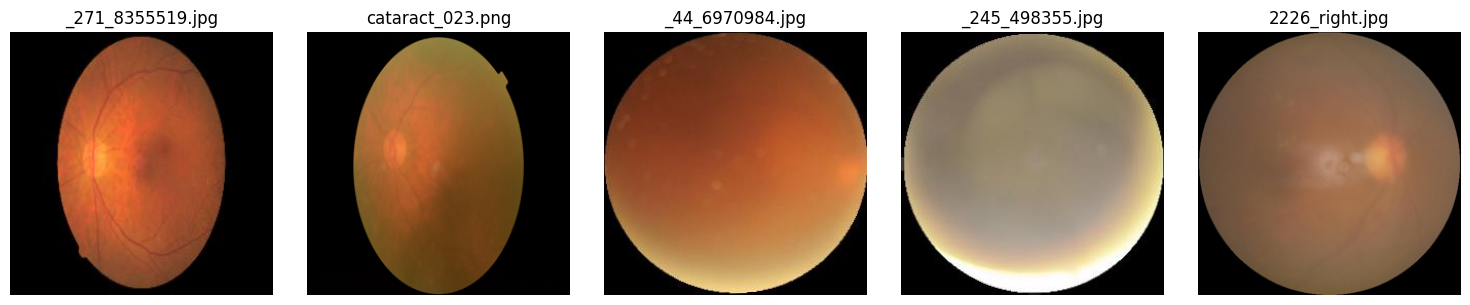

In [13]:
# Specify the path containing the images to visualize
path_to_visualize = "dataset/cataract"

# Visualize 5 random images
visualize_images(path_to_visualize, num_images=5)

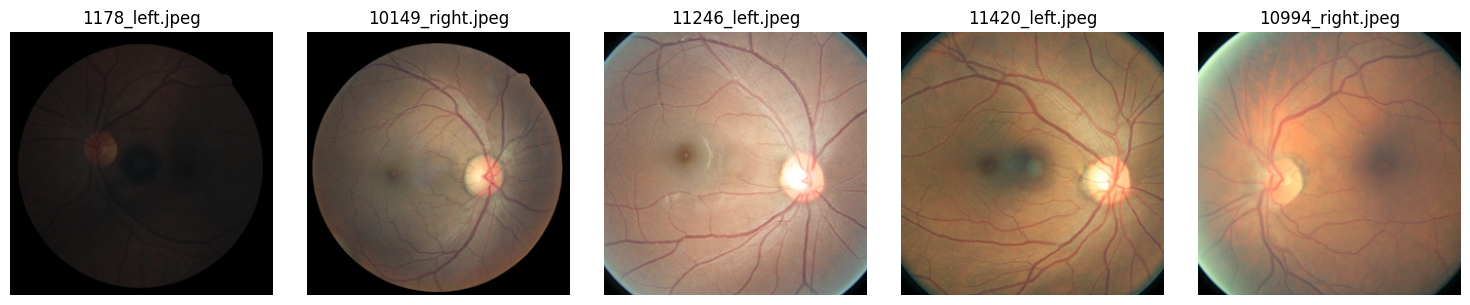

In [14]:
# Specify the path containing the images to visualize
path_to_visualize = "dataset/diabetic_retinopathy"

# Visualize 5 random images
visualize_images(path_to_visualize, num_images=5)

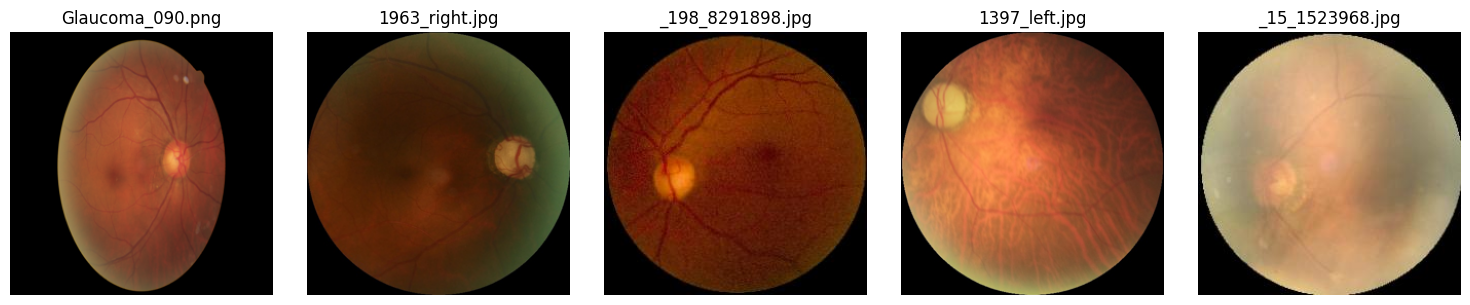

In [15]:
# Specify the path containing the images to visualize
path_to_visualize = "dataset/glaucoma"

# Visualize 5 random images
visualize_images(path_to_visualize, num_images=5)

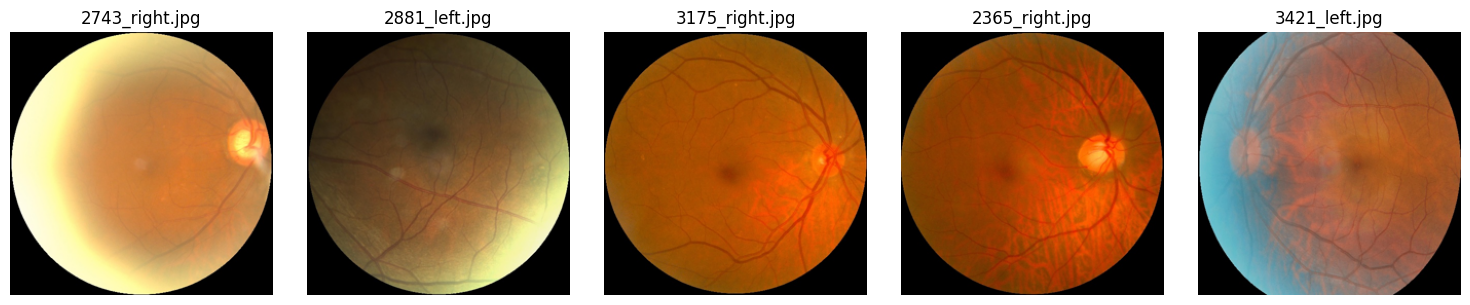

In [16]:
# Specify the path containing the images to visualize
path_to_visualize = "dataset/normal"

# Visualize 5 random images
visualize_images(path_to_visualize, num_images=5)

In [17]:
# for faster training which takes less time and less memory for training
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [18]:
# Augmentation for training dataset
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.5)
])

In [19]:
import tensorflow as tf

# 1. Instantiate MobileNetV2 with built-in pooling
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(256, 256, 3),
    pooling='avg'  # This outputs a 2D tensor: (None, 1280)
)

# 2. Build the model architecture without a duplicate global pooling layer
inputs = tf.keras.Input(shape=(256, 256, 3))
x = inputs
x = base_model(x, training=False)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Let's take a look at the base model architecture
base_model.summary()

# Define EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(patience=3)

# Train the model with early stopping
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stopping]  # Add the EarlyStopping callback to the training process
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

Epoch 1/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 174s 730ms/step - accuracy: 0.8207 - loss: 0.4700 - val_accuracy: 0.2598 - val_loss: 3.1962
Epoch 2/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.9597 - loss: 0.1237 - val_accuracy: 0.3499 - val_loss: 2.2718
Epoch 3/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.9959 - loss: 0.0316 - val_accuracy: 0.5243 - val_loss: 1.5461
Epoch 4/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 132ms/step - accuracy: 1.0000 - loss: 0.0091 - val_accuracy: 0.5824 - val_loss: 1.4871
Epoch 5/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.6323 - val_loss: 1.3786
Epoch 6/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.6785 - val_loss: 1.1348
Epoch 7/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.7319 - val_loss: 0.9354
Epoch 8/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 130ms/step - accuracy: 1.0000 - loss: 

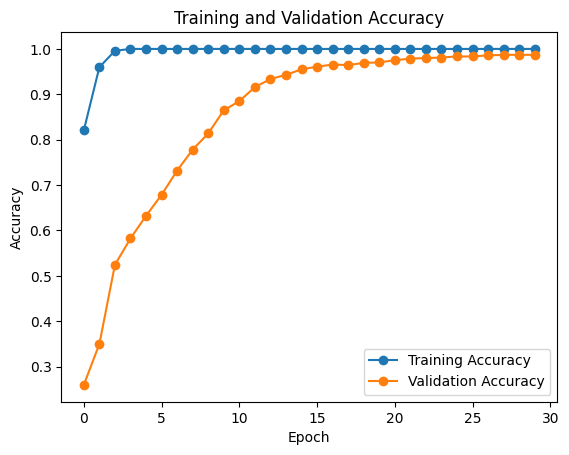

In [20]:
# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

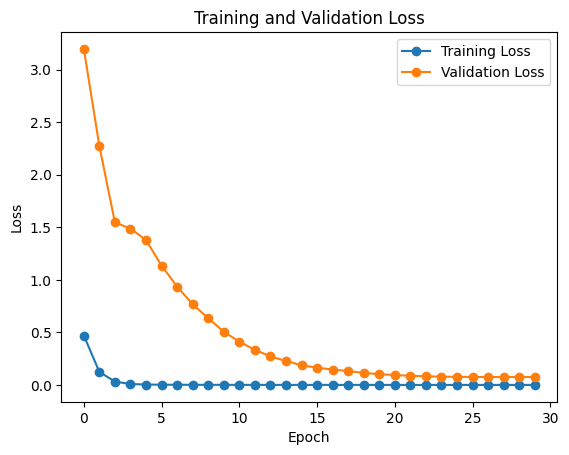

In [21]:
# Plot training history
plt.plot(history.history['loss'], label='Training Loss',marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [22]:
def predict(model, img):
    img_array = tf.keras.utils.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100*(np.max(predictions[0])), 0)
    return predicted_class, confidence


1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


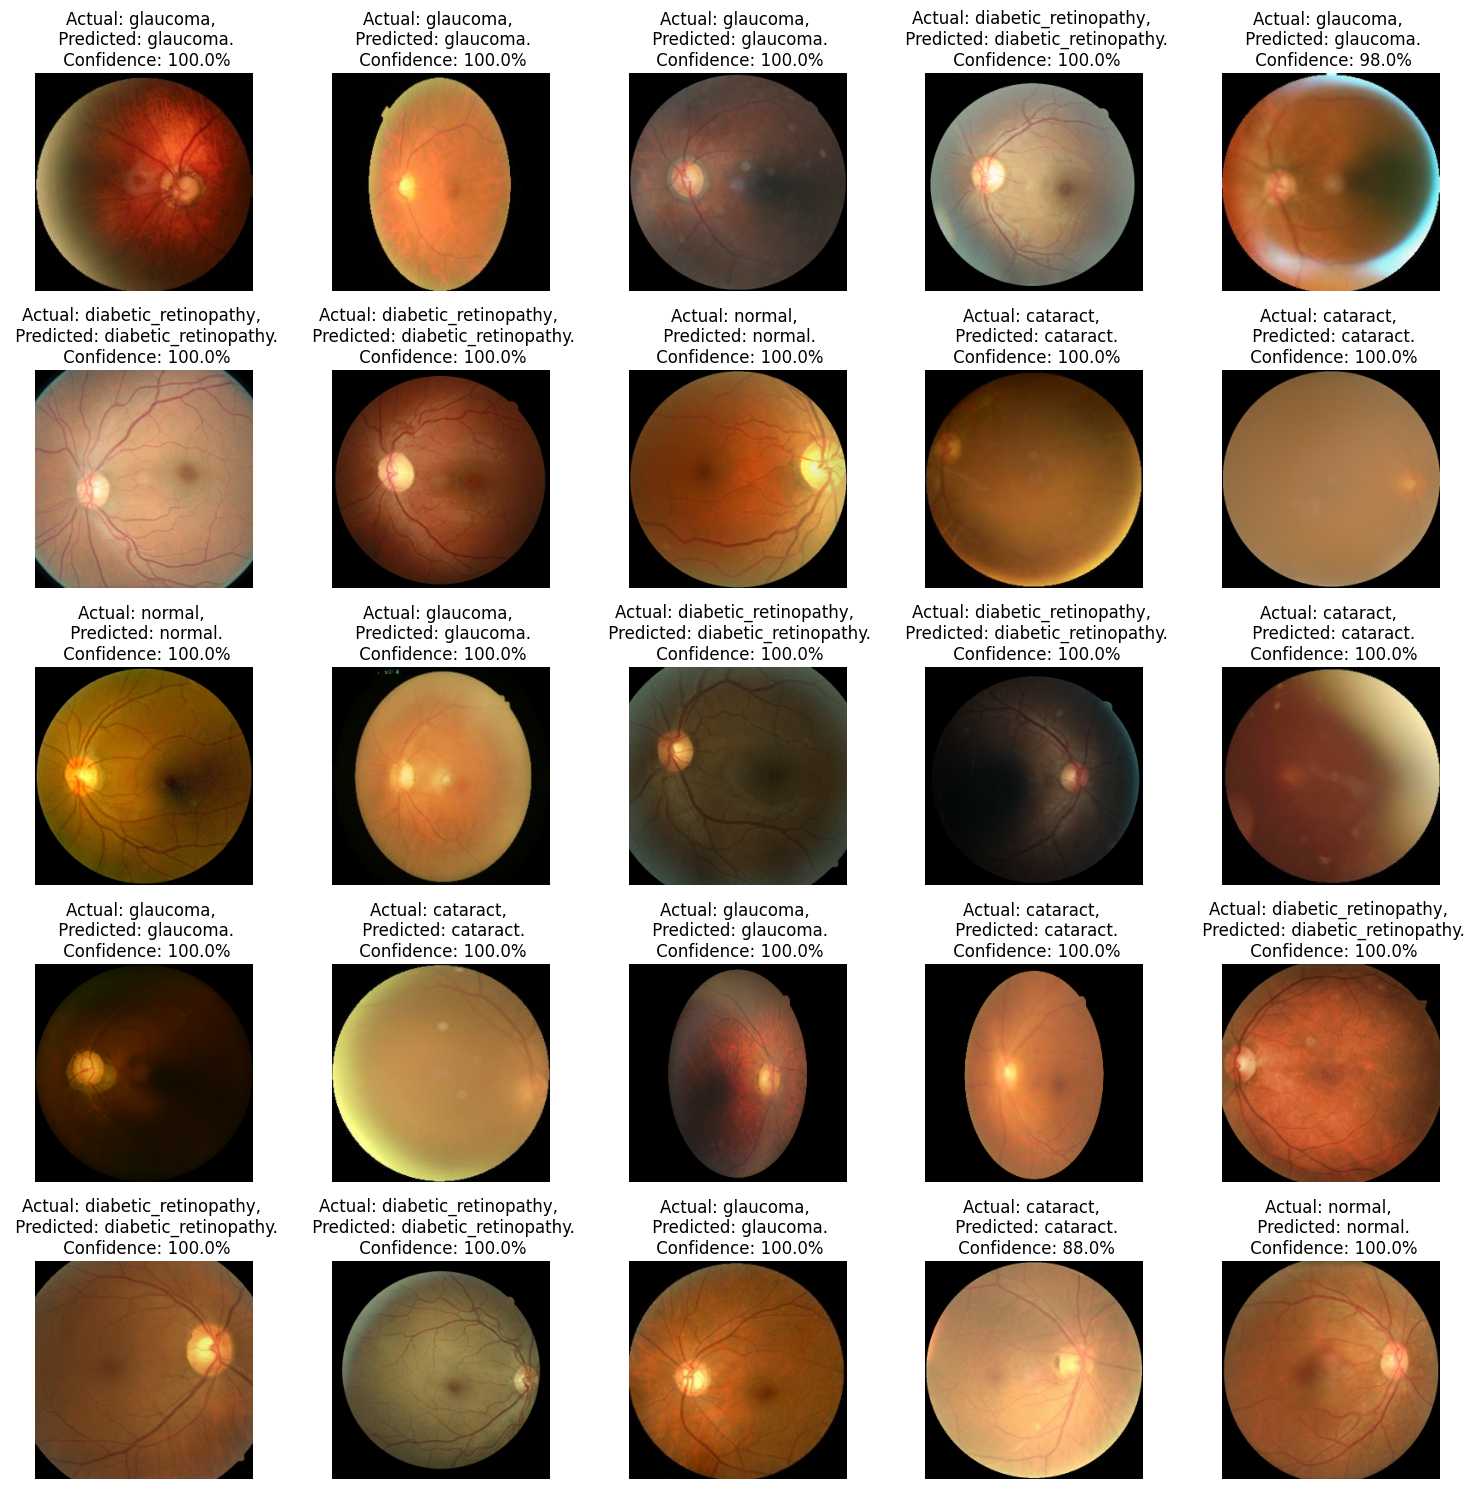

In [23]:
# Assuming val_ds is your validation dataset
plt.figure(figsize=(15, 15))
for images, labels in val_ds.take(1):
    for i in range(25):
        ax = plt.subplot(5, 5, i+1)  # Adjust the subplot layout as per your preference
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis('off')

plt.tight_layout()
plt.show()

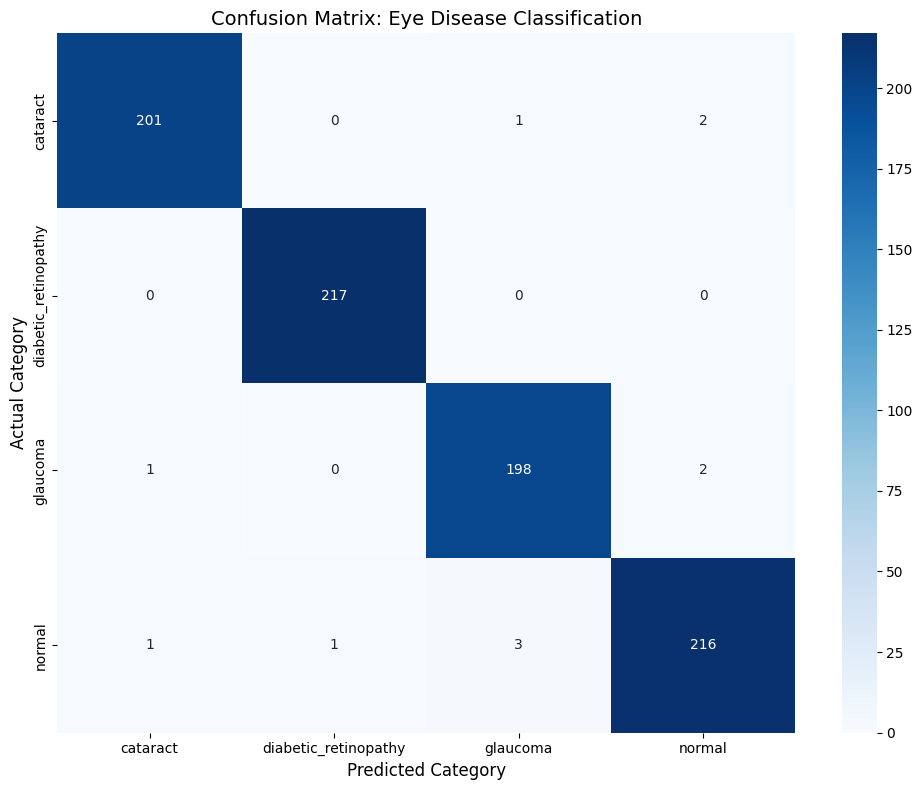

                      precision    recall  f1-score   support

            cataract       0.99      0.99      0.99       204
diabetic_retinopathy       1.00      1.00      1.00       217
            glaucoma       0.98      0.99      0.98       201
              normal       0.98      0.98      0.98       221

            accuracy                           0.99       843
           macro avg       0.99      0.99      0.99       843
        weighted avg       0.99      0.99      0.99       843



In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def get_predictions_and_labels(model, dataset):
    """Iterates through the dataset and returns all true and predicted labels."""
    all_true_labels = []
    all_predicted_labels = []

    for images, labels in dataset:
        # 1. Get model predictions
        preds = model.predict(images, verbose=0)

        # 2. Get indices of the highest probability
        predicted_indices = np.argmax(preds, axis=1)

        # 3. Store results
        all_true_labels.extend(labels.numpy())
        all_predicted_labels.extend(predicted_indices)

    return np.array(all_true_labels), np.array(all_predicted_labels)

# --- EXECUTION ---

# 1. Collect results from your validation dataset
y_true, y_pred = get_predictions_and_labels(model, val_ds)

# 2. Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix: Eye Disease Classification', fontsize=14)
plt.ylabel('Actual Category', fontsize=12)
plt.xlabel('Predicted Category', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_results.png')
plt.show()

# 4. (Optional) Print text report for Precision, Recall, and F1-Score
print(classification_report(y_true, y_pred, target_names=class_names))

In [25]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Ensure y_true and y_pred are already generated from your evaluation function
# y_true, y_pred = get_predictions_and_labels(model, val_ds)

# ==========================================
# 1. ACCURACY SCORE
# ==========================================
acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")


# ==========================================
# 2. PRECISION (Per-Class & Averages)
# ==========================================
# 'macro': unweighted mean, 'weighted': support-weighted mean
prec_per_class = precision_score(y_true, y_pred, average=None)
prec_macro = precision_score(y_true, y_pred, average='macro')
prec_weighted = precision_score(y_true, y_pred, average='weighted')

print("\n--- Precision ---")
for name, p in zip(class_names, prec_per_class):
    print(f"Class '{name}': {p:.4f}")
print(f"Macro Precision: {prec_macro:.4f}")
print(f"Weighted Precision: {prec_weighted:.4f}")


# ==========================================
# 3. RECALL / SENSITIVITY (Per-Class & Averages)
# ==========================================
recall_per_class = recall_score(y_true, y_pred, average=None)
recall_macro = recall_score(y_true, y_pred, average='macro')
recall_weighted = recall_score(y_true, y_pred, average='weighted')

print("\n--- Recall (Sensitivity) ---")
for name, r in zip(class_names, recall_per_class):
    print(f"Class '{name}': {r:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Weighted Recall: {recall_weighted:.4f}")


# ==========================================
# 4. F1-SCORE (Per-Class & Averages)
# ==========================================
f1_per_class = f1_score(y_true, y_pred, average=None)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("\n--- F1-Score ---")
for name, f in zip(class_names, f1_per_class):
    print(f"Class '{name}': {f:.4f}")
print(f"Macro F1-Score: {f1_macro:.4f}")
print(f"Weighted F1-Score: {f1_weighted:.4f}")


# ==========================================
# 5. CONFUSION MATRIX (Extracting TP, FP, FN, TN per class)
# ==========================================
cm = confusion_matrix(y_true, y_pred)
print("\n--- Confusion Matrix breakdown per class ---")

for i, class_name in enumerate(class_names):
    true_positives = cm[i, i]
    false_positives = cm[:, i].sum() - true_positives
    false_negatives = cm[i, :].sum() - true_positives
    true_negatives = cm.sum() - (true_positives + false_positives + false_negatives)

    print(f"Class: {class_name}")
    print(f"  TP: {true_positives} | FP: {false_positives} | FN: {false_negatives} | TN: {true_negatives}")


# ==========================================
# 6. COMPLETE CLASSIFICATION REPORT (All-in-One)
# ==========================================
print("\n--- Full Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Overall Accuracy: 98.70%

--- Precision ---
Class 'cataract': 0.9901
Class 'diabetic_retinopathy': 0.9954
Class 'glaucoma': 0.9802
Class 'normal': 0.9818
Macro Precision: 0.9869
Weighted Precision: 0.9869

--- Recall (Sensitivity) ---
Class 'cataract': 0.9853
Class 'diabetic_retinopathy': 1.0000
Class 'glaucoma': 0.9851
Class 'normal': 0.9774
Macro Recall: 0.9869
Weighted Recall: 0.9870

--- F1-Score ---
Class 'cataract': 0.9877
Class 'diabetic_retinopathy': 0.9977
Class 'glaucoma': 0.9826
Class 'normal': 0.9796
Macro F1-Score: 0.9869
Weighted F1-Score: 0.9869

--- Confusion Matrix breakdown per class ---
Class: cataract
  TP: 201 | FP: 2 | FN: 3 | TN: 637
Class: diabetic_retinopathy
  TP: 217 | FP: 1 | FN: 0 | TN: 625
Class: glaucoma
  TP: 198 | FP: 4 | FN: 3 | TN: 638
Class: normal
  TP: 216 | FP: 4 | FN: 5 | TN: 618

--- Full Classification Report ---
                      precision    recall  f1-score   support

            cataract     0.9901    0.9853    0.9877       204
diabetic

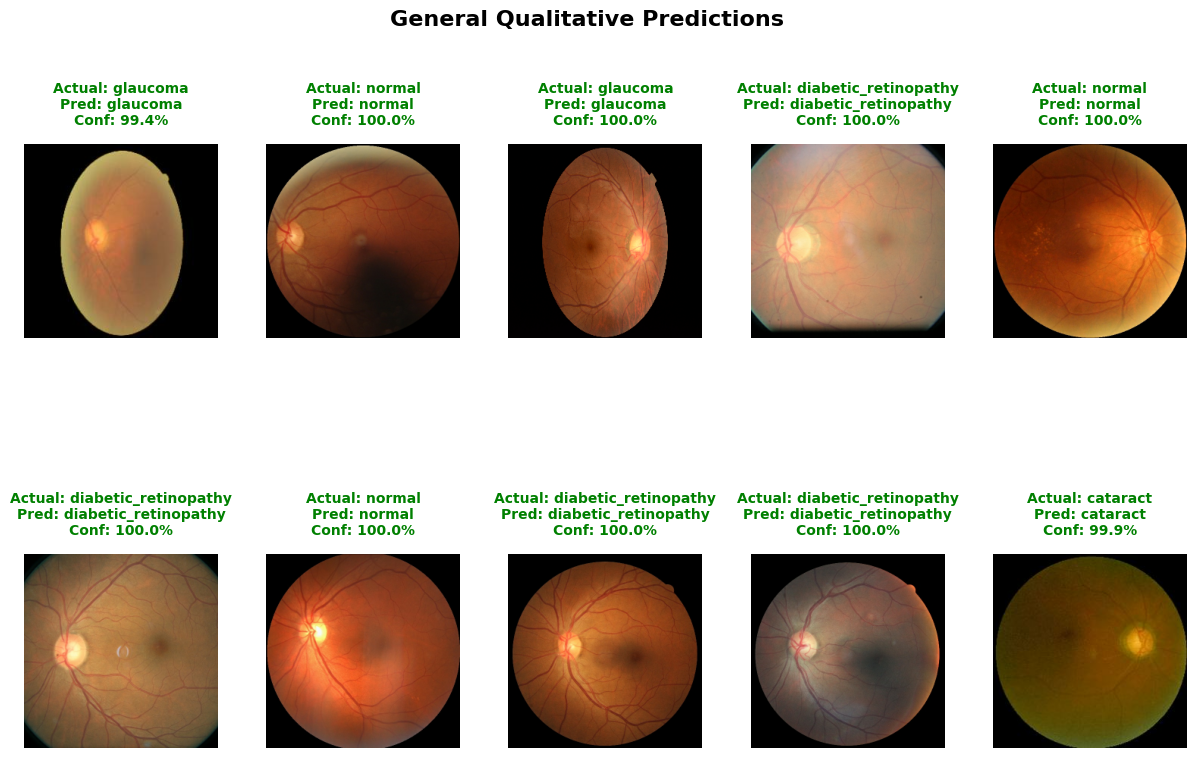

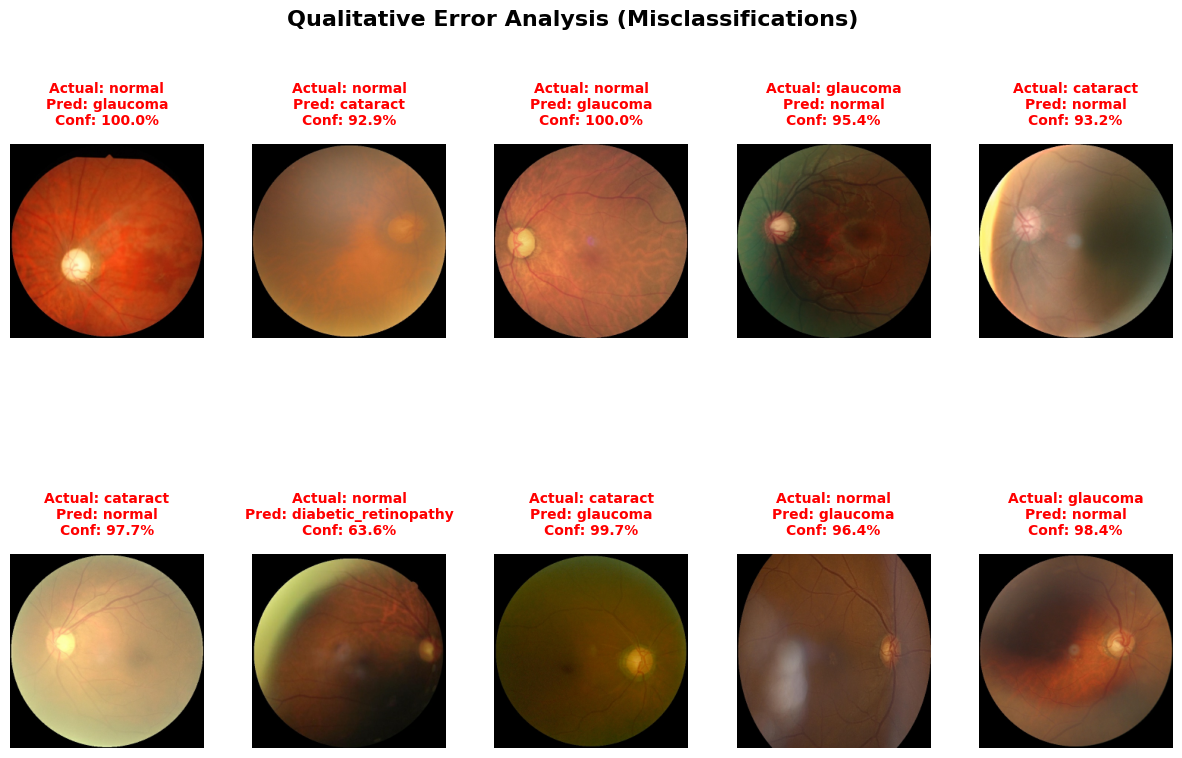

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def plot_qualitative_results(model, dataset, class_names, num_images=10, show_errors_only=False):
    """
    Plots qualitative results from a dataset, displaying the image,
    actual class, predicted class, and confidence percentage with proper spacing.

    Args:
        model: Trained Keras model.
        dataset: TensorFlow dataset (e.g., val_ds).
        class_names: List of class label strings.
        num_images: Number of sample images to display.
        show_errors_only: If True, filters specifically for misclassifications.
    """
    images_list = []
    true_labels_list = []
    pred_labels_list = []
    confidences_list = []

    # Iterate through the dataset to collect predictions
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        pred_indices = np.argmax(preds, axis=1)
        confidences = np.max(preds, axis=1) * 100

        for i in range(len(images)):
            images_list.append(images[i].numpy())
            true_labels_list.append(labels[i].numpy())
            pred_labels_list.append(pred_indices[i])
            confidences_list.append(confidences[i])

    images_arr = np.array(images_list)
    true_arr = np.array(true_labels_list)
    pred_arr = np.array(pred_labels_list)
    conf_arr = np.array(confidences_list)

    # Filter indices based on whether we want all samples or just errors
    if show_errors_only:
        indices = np.where(true_arr != pred_arr)[0]
        plot_title = "Qualitative Error Analysis (Misclassifications)"
    else:
        indices = np.arange(len(images_arr))
        plot_title = "General Qualitative Predictions"

    if len(indices) == 0:
        print("No images found matching the criteria!")
        return

    # Randomly sample from the available indices
    selected_indices = np.random.choice(
        indices,
        size=min(num_images, len(indices)),
        replace=False
    )

    # Set up the plotting grid (5 columns wide) with expanded figure height
    cols = 5
    rows = (len(selected_indices) + cols - 1) // cols
    plt.figure(figsize=(15, 4.5 * rows))

    for idx, i in enumerate(selected_indices):
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(images_arr[i].astype("uint8"))

        actual = class_names[true_arr[i]]
        predicted = class_names[pred_arr[i]]
        conf = conf_arr[i]

        # Color code: Green if correct, Red if incorrect
        is_correct = (true_arr[i] == pred_arr[i])
        title_color = 'green' if is_correct else 'red'

        # Added pad parameter to leave physical breathing room above the image
        plt.title(
            f"Actual: {actual}\nPred: {predicted}\nConf: {conf:.1f}%",
            color=title_color,
            fontsize=10,
            fontweight='bold',
            pad=14
        )
        plt.axis('off')

    plt.suptitle(plot_title, fontsize=16, y=0.98, fontweight='bold')

    # Explicitly add vertical and horizontal spacing between grid cells
    plt.subplots_adjust(hspace=0.45, wspace=0.25)
    plt.show()

# --- EXECUTION EXAMPLES ---

# 1. Plot a random qualitative sample of predictions
plot_qualitative_results(model, val_ds, class_names, num_images=10, show_errors_only=False)

# 2. Plot qualitative error analysis (focus exclusively on where the model failed)
plot_qualitative_results(model, val_ds, class_names, num_images=10, show_errors_only=True)

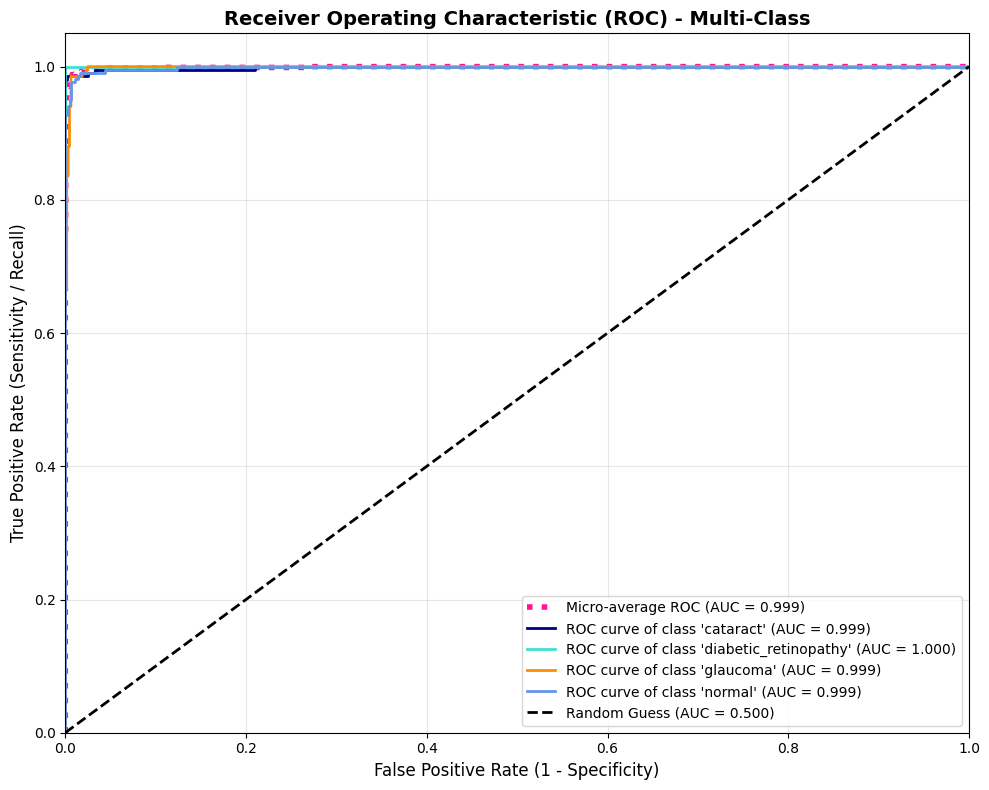

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_multiclass_roc(model, dataset, class_names):
    """
    Computes and plots ROC curves (Receiver Operating Characteristic)
    and AUC (Area Under the Curve) for multi-class classification models.
    """
    all_true_labels = []
    all_pred_probs = []

    # 1. Collect true labels and raw predicted probability distributions
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_true_labels.extend(labels.numpy())
        all_pred_probs.extend(preds)

    y_true = np.array(all_true_labels)
    y_score = np.array(all_pred_probs)
    n_classes = len(class_names)

    # 2. Binarize the true labels for multi-class ROC analysis
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    # 3. Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # 4. Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # 5. Plot all ROC curves
    plt.figure(figsize=(10, 8))

    # Plot micro-average ROC curve
    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})",
        color="deeppink",
        linestyle=":",
        linewidth=4,
    )

    # Plot individual class ROC curves
    colors = ['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'green', 'purple']
    for i, color in zip(range(n_classes), colors[:n_classes]):
        plt.plot(
            fpr[i],
            tpr[i],
            color=color,
            lw=2,
            label=f"ROC curve of class '{class_names[i]}' (AUC = {roc_auc[i]:.3f})",
        )

    # Plot diagonal reference line (random classifier)
    plt.plot([0, 1], [0, 1], "k--", lw=2, label="Random Guess (AUC = 0.500)")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
    plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
    plt.title("Receiver Operating Characteristic (ROC) - Multi-Class", fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve_results.png', dpi=300)
    plt.show()

# --- EXECUTION ---
plot_multiclass_roc(model, val_ds, class_names)

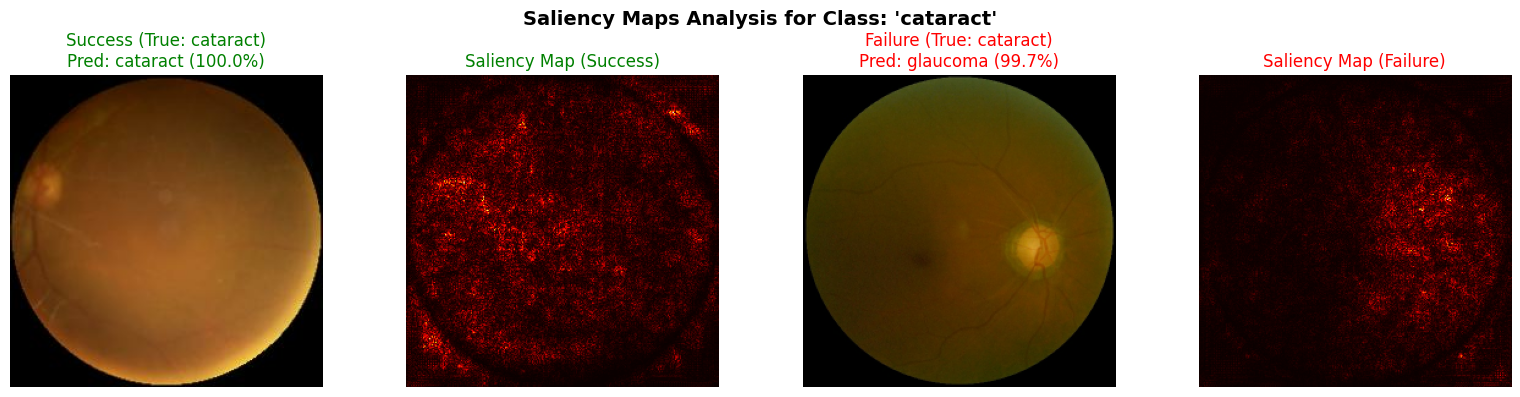

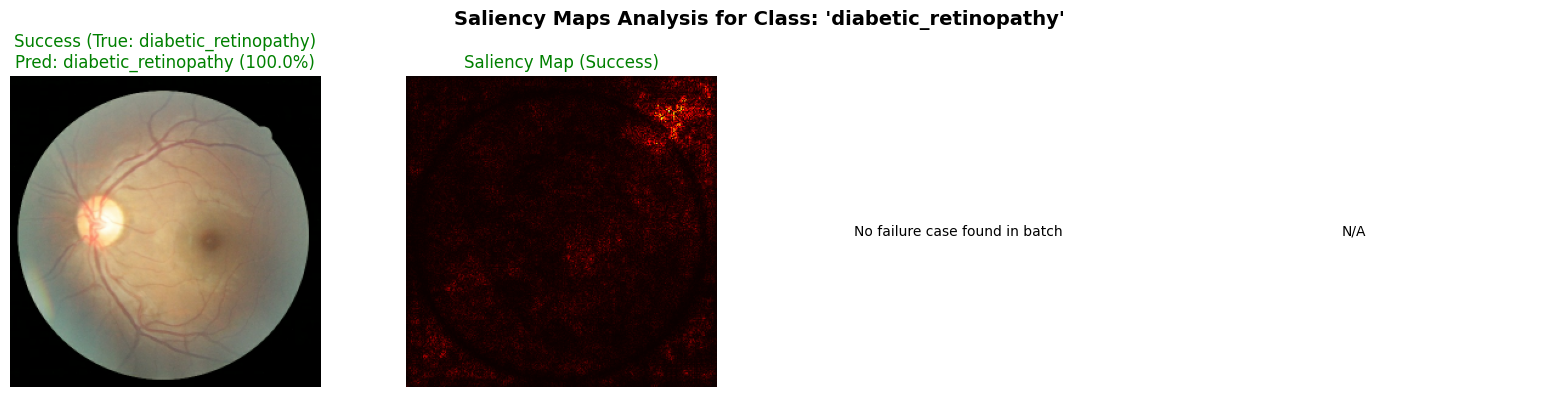

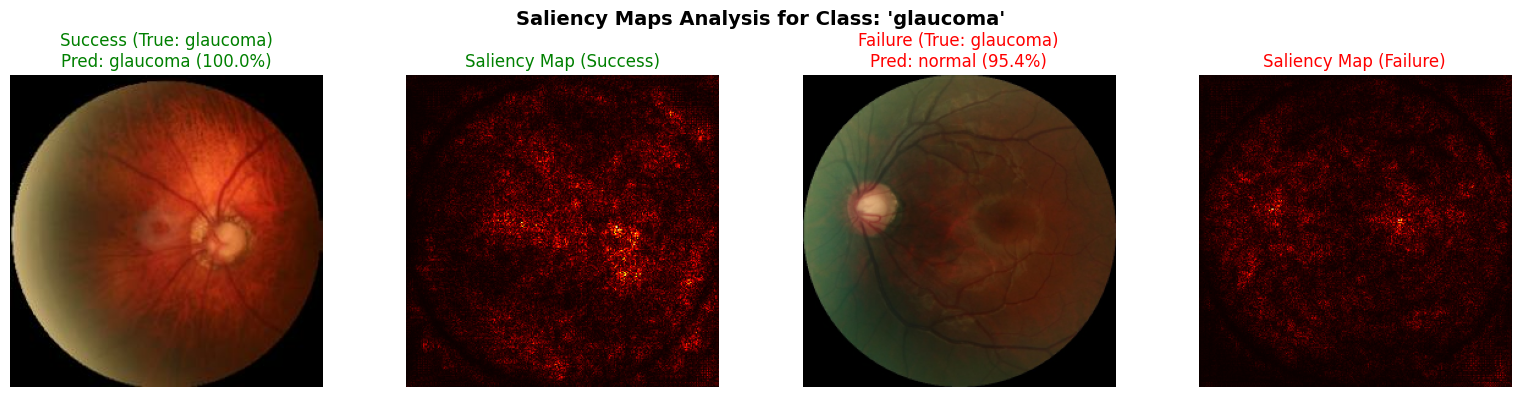

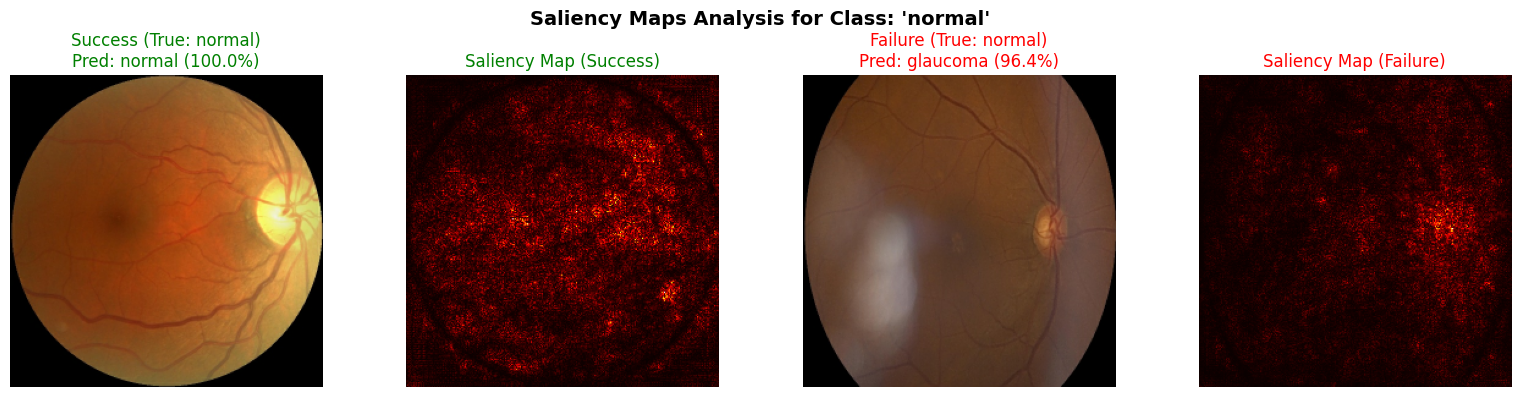

In [28]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def generate_saliency_map(model, img_tensor, pred_index):
    """
    Computes a gradient-based saliency map for a given input image and target class.
    """
    img_tensor = tf.cast(img_tensor, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor, training=False)
        loss = preds[:, pred_index]

    # Calculate gradients of the loss with respect to the input image
    grads = tape.gradient(loss, img_tensor)

    # Take max across color channels and absolute values for visualization
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]

    # Normalize between 0 and 1
    saliency = (saliency - tf.reduce_min(saliency)) / (tf.reduce_max(saliency) - tf.reduce_min(saliency) + 1e-8)
    return saliency.numpy()

def plot_class_saliency_cases(model, dataset, class_names):
    """
    Finds and plots successful and failed prediction cases for each class
    along with their computed saliency maps.
    """
    class_data = {i: {'success': None, 'failure': None} for i in range(len(class_names))}

    # 1. Scan dataset to collect one success and one failure per class
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        pred_indices = np.argmax(preds, axis=1)

        for i in range(len(images)):
            true_lbl = labels[i].numpy()
            pred_lbl = pred_indices[i]

            # Check for success (Correct prediction)
            if true_lbl == pred_lbl and class_data[true_lbl]['success'] is None:
                class_data[true_lbl]['success'] = (images[i], pred_lbl, preds[i])

            # Check for failure (Misclassification)
            elif true_lbl != pred_lbl and class_data[true_lbl]['failure'] is None:
                class_data[true_lbl]['failure'] = (images[i], pred_lbl, preds[i])

            # Stop if we found both for all classes
            if all(d['success'] is not None and d['failure'] is not None for d in class_data.values()):
                break
        else:
            continue
        break

    # 2. Plot results for each class
    for class_idx, name in enumerate(class_names):
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        fig.suptitle(f"Saliency Maps Analysis for Class: '{name}'", fontsize=14, fontweight='bold')

        # --- SUCCESS CASE ---
        succ = class_data[class_idx]['success']
        if succ is not None:
            img_succ, pred_succ, prob_succ = succ
            img_tensor = tf.expand_dims(img_succ, 0)
            saliency_succ = generate_saliency_map(model, img_tensor, class_idx)

            axes[0].imshow(img_succ.numpy().astype("uint8"))
            axes[0].set_title(f"Success (True: {name})\nPred: {class_names[pred_succ]} ({100*np.max(prob_succ):.1f}%)", color='green')
            axes[0].axis('off')

            axes[1].imshow(saliency_succ, cmap='hot')
            axes[1].set_title("Saliency Map (Success)", color='green')
            axes[1].axis('off')
        else:
            axes[0].text(0.5, 0.5, "No success case found in batch", ha='center', va='center')
            axes[1].text(0.5, 0.5, "N/A", ha='center', va='center')
            axes[0].axis('off'); axes[1].axis('off')

        # --- FAILURE CASE ---
        fail = class_data[class_idx]['failure']
        if fail is not None:
            img_fail, pred_fail, prob_fail = fail
            img_tensor = tf.expand_dims(img_fail, 0)
            saliency_fail = generate_saliency_map(model, img_tensor, pred_fail)

            axes[2].imshow(img_fail.numpy().astype("uint8"))
            axes[2].set_title(f"Failure (True: {name})\nPred: {class_names[pred_fail]} ({100*np.max(prob_fail):.1f}%)", color='red')
            axes[2].axis('off')

            axes[3].imshow(saliency_fail, cmap='hot')
            axes[3].set_title("Saliency Map (Failure)", color='red')
            axes[3].axis('off')
        else:
            axes[2].text(0.5, 0.5, "No failure case found in batch", ha='center', va='center')
            axes[3].text(0.5, 0.5, "N/A", ha='center', va='center')
            axes[2].axis('off'); axes[3].axis('off')

        plt.tight_layout()
        plt.show()

# --- EXECUTION ---
plot_class_saliency_cases(model, val_ds, class_names)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

def compute_dataset_auc(model, dataset, n_classes):
    """Helper function to calculate macro-average ROC AUC for a dataset."""
    all_true_labels = []
    all_pred_probs = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_true_labels.extend(labels.numpy())
        all_pred_probs.extend(preds)

    y_true = np.array(all_true_labels)
    y_score = np.array(all_pred_probs)

    # Binarize labels for multi-class AUC calculation
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    # Compute multi-class ROC AUC (macro average)
    try:
        auc_score = roc_auc_score(y_true_bin, y_score, average='macro', multi_class='ovr')
    except ValueError:
        auc_score = 0.5  # Fallback if a batch lacks representation for a class

    return auc_score

def evaluate_epoch_auc_history(model, train_ds, val_ds, class_names, epochs_to_evaluate=None):
    """
    Evaluates and plots AUC progression.
    Note: Standard Keras model.fit() does not natively compute AUC per epoch
    unless explicitly added to `metrics=['accuracy', tf.keras.metrics.AUC()]`.
    If you already included AUC in your compile metrics, you can pull it directly
    from `history.history`. Otherwise, this function computes it.
    """
    n_classes = len(class_names)

    # If AUC was added to compile metrics: model.compile(..., metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    if 'auc' in history.history and 'val_auc' in history.history:
        print("Extracting AUC directly from training history...")
        train_auc = history.history['auc']
        val_auc = history.history['val_auc']
    else:
        print("Computing AUC across epochs (Evaluating current model state)...")
        # If evaluating a pre-trained model once:
        train_auc_score = compute_dataset_auc(model, train_ds, n_classes)
        val_auc_score = compute_dataset_auc(model, val_ds, n_classes)

        print(f"Training Macro AUC: {train_auc_score:.4f}")
        print(f"Validation Macro AUC: {val_auc_score:.4f}")
        return

    # Plot Training vs Validation AUC curves over epochs
    plt.figure(figsize=(8, 6))
    plt.plot(train_auc, label='Training AUC', marker='o', color='darkorange')
    plt.plot(val_auc, label='Validation AUC', marker='o', color='royalblue')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Area Under ROC Curve (AUC)', fontsize=12)
    plt.title('Training and Validation AUC per Epoch', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('auc_training_validation_curves.png', dpi=300)
    plt.show()

# --- EXECUTION ---
# Recommendation: To track AUC dynamically during future training runs,
# add `tf.keras.metrics.AUC(name='auc')` to your model compilation metrics list:
# model.compile(optimizer=optimizer, loss=..., metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

evaluate_epoch_auc_history(model, train_ds, val_ds, class_names)

Computing AUC across epochs (Evaluating current model state)...
Training Macro AUC: 1.0000
Validation Macro AUC: 0.9990


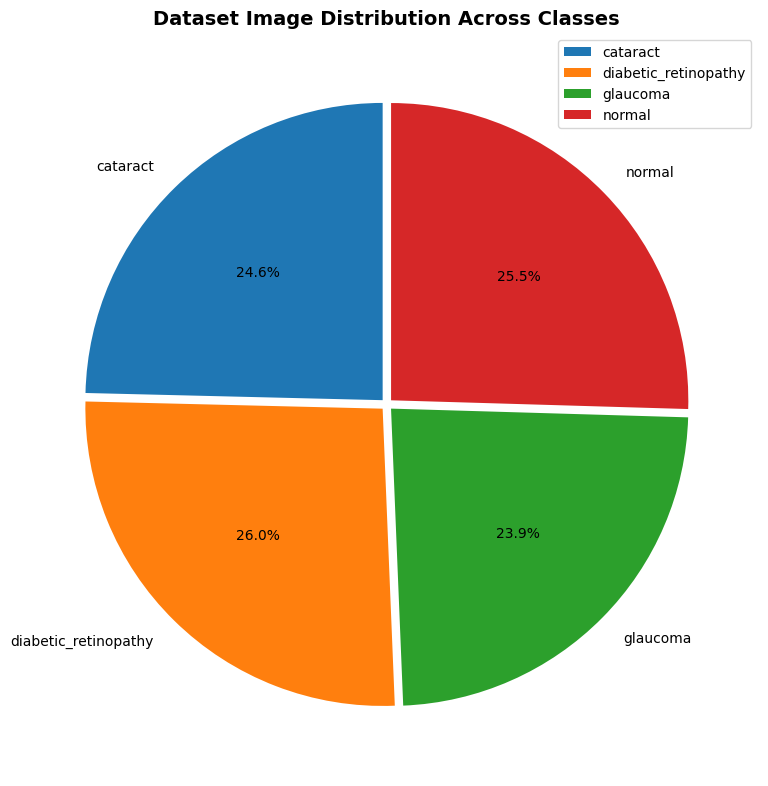

In [30]:
import os
import matplotlib.pyplot as plt

def plot_class_distribution(train_dir, class_names):
    """
    Counts the number of images in each class directory and plots a pie chart
    showing the dataset distribution.
    """
    class_counts = []

    # Count files in each class subdirectory
    for class_name in class_names:
        class_path = os.path.join(train_dir, class_name)
        if os.path.exists(class_path):
            # Count valid image files
            num_files = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
            class_counts.append(num_files)
        else:
            class_counts.append(0)

    # Plotting the pie chart
    plt.figure(figsize=(8, 8))
    plt.pie(
        class_counts,
        labels=class_names,
        autopct='%1.1f%%',
        startangle=90,
        explode=[0.02] * len(class_names), # Slight separation for clarity
        shadow=False
    )
    plt.title('Dataset Image Distribution Across Classes', fontsize=14, fontweight='bold')
    plt.legend(loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.savefig('class_image_distribution_pie.png', dpi=300)
    plt.show()

# --- EXECUTION ---
# Ensure train_dir matches your active path variable (e.g., 'dataset' or cloned repo path)
plot_class_distribution(train_dir, class_names)

           PERFORMANCE METRICS            
Overall Accuracy:     98.70%
Macro Sensitivity:    98.69%
Macro Specificity:    99.57%
Inference Time/Batch: Mean = 0.1470s | StdDev = 0.0408s
------------------------------------------
Per-Class Breakdown:
  Class 'cataract':
    - Sensitivity: 98.53%
    - Specificity: 99.69%
  Class 'diabetic_retinopathy':
    - Sensitivity: 100.00%
    - Specificity: 99.84%
  Class 'glaucoma':
    - Sensitivity: 98.51%
    - Specificity: 99.38%
  Class 'normal':
    - Sensitivity: 97.74%
    - Specificity: 99.36%

--- Structured Summary Table ---
| Metric                  | Value    |
|:------------------------|:---------|
| Overall Accuracy        | 98.70%   |
| Macro Sensitivity       | 98.69%   |
| Macro Specificity       | 99.57%   |
| Inference Time (Mean)   | 0.1470 s |
| Inference Time (StdDev) | 0.0408 s |


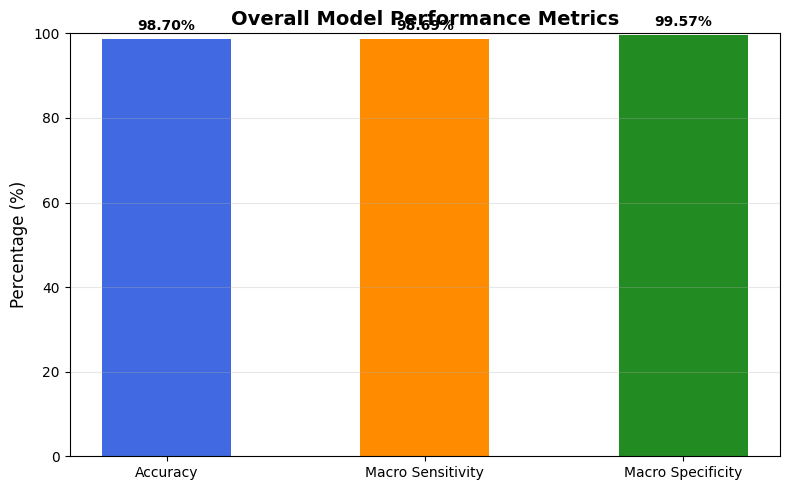

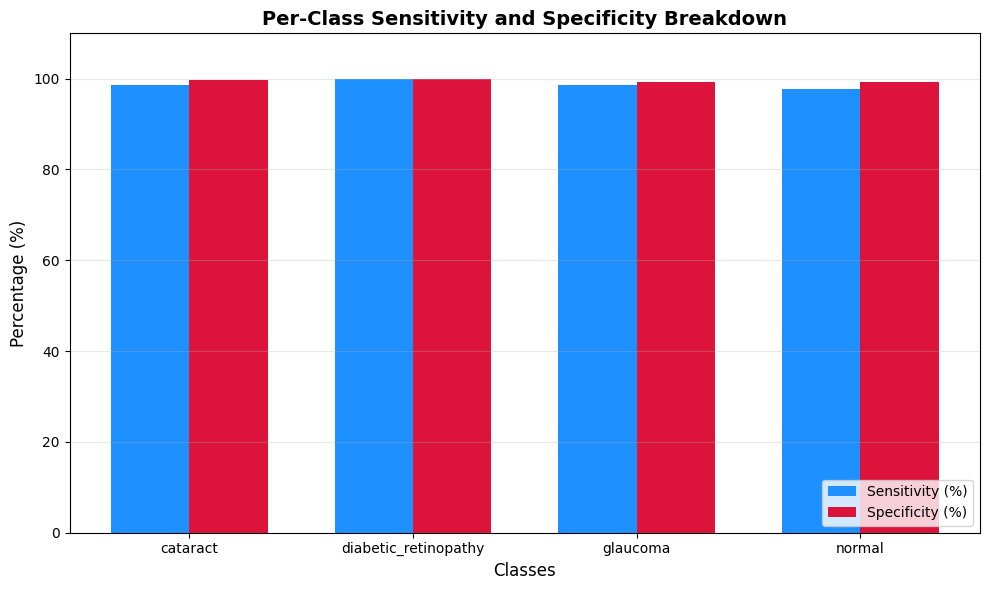

In [31]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

def evaluate_and_plot_performance(model, dataset, class_names):
    """
    Computes Accuracy, Sensitivity (Recall), Specificity, and Inference Time statistics,
    displays a structured Pandas markdown table, and automatically generates
    and saves both overall and per-class performance visualization charts.
    """
    all_true_labels = []
    all_pred_labels = []
    batch_times = []

    n_classes = len(class_names)

    # 1. Evaluate Dataset & Measure Inference Times
    for images, labels in dataset:
        start_time = time.time()
        preds = model.predict(images, verbose=0)
        end_time = time.time()

        batch_duration = end_time - start_time
        batch_times.append(batch_duration)

        pred_indices = np.argmax(preds, axis=1)
        all_true_labels.extend(labels.numpy())
        all_pred_labels.extend(pred_indices)

    y_true = np.array(all_true_labels)
    y_pred = np.array(all_pred_labels)

    # 2. Calculate Quantitative Metrics
    accuracy = accuracy_score(y_true, y_pred) * 100
    sensitivity_per_class = recall_score(y_true, y_pred, average=None) * 100
    macro_sensitivity = np.mean(sensitivity_per_class)

    cm = confusion_matrix(y_true, y_pred)
    specificity_per_class = []

    for i in range(n_classes):
        true_positives = cm[i, i]
        false_positives = cm[:, i].sum() - true_positives
        false_negatives = cm[i, :].sum() - true_positives
        true_negatives = cm.sum() - (true_positives + false_positives + false_negatives)

        specificity = (true_negatives / (true_negatives + false_positives)) * 100 if (true_negatives + false_positives) > 0 else 0.0
        specificity_per_class.append(specificity)

    macro_specificity = np.mean(specificity_per_class)

    mean_time = np.mean(batch_times)
    std_time = np.std(batch_times)

    # 3. Print Text Summary
    print("==========================================")
    print("           PERFORMANCE METRICS            ")
    print("==========================================")
    print(f"Overall Accuracy:     {accuracy:.2f}%")
    print(f"Macro Sensitivity:    {macro_sensitivity:.2f}%")
    print(f"Macro Specificity:    {macro_specificity:.2f}%")
    print(f"Inference Time/Batch: Mean = {mean_time:.4f}s | StdDev = {std_time:.4f}s")
    print("------------------------------------------")
    print("Per-Class Breakdown:")
    for idx, name in enumerate(class_names):
        print(f"  Class '{name}':")
        print(f"    - Sensitivity: {sensitivity_per_class[idx]:.2f}%")
        print(f"    - Specificity: {specificity_per_class[idx]:.2f}%")
    print("==========================================")

    # 4. Generate Markdown Table DataFrame
    metrics_data = {
        "Metric": [
            "Overall Accuracy",
            "Macro Sensitivity",
            "Macro Specificity",
            "Inference Time (Mean)",
            "Inference Time (StdDev)"
        ],
        "Value": [
            f"{accuracy:.2f}%",
            f"{macro_sensitivity:.2f}%",
            f"{macro_specificity:.2f}%",
            f"{mean_time:.4f} s",
            f"{std_time:.4f} s"
        ]
    }
    df_metrics = pd.DataFrame(metrics_data)
    print("\n--- Structured Summary Table ---")
    print(df_metrics.to_markdown(index=False))

    # 5. Plot and Save Visualizations
    # Plot 1: Overall Metrics Bar Chart
    metrics_names = ['Accuracy', 'Macro Sensitivity', 'Macro Specificity']
    metrics_values = [accuracy, macro_sensitivity, macro_specificity]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(metrics_names, metrics_values, color=['royalblue', 'darkorange', 'forestgreen'], width=0.5)
    plt.ylim(0, 100)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.title('Overall Model Performance Metrics', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1.5, f'{height:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('overall_performance_bar_chart.png', dpi=300)
    plt.show()

    # Plot 2: Per-Class Sensitivity vs Specificity Grouped Bar Chart
    x = np.arange(len(class_names))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, sensitivity_per_class, width, label='Sensitivity (%)', color='dodgerblue')
    plt.bar(x + width/2, specificity_per_class, width, label='Specificity (%)', color='crimson')

    plt.xlabel('Classes', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.title('Per-Class Sensitivity and Specificity Breakdown', fontsize=14, fontweight='bold')
    plt.xticks(x, class_names, fontsize=10)
    plt.ylim(0, 110)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('per_class_performance_bar_chart.png', dpi=300)
    plt.show()

    return {
        "accuracy": accuracy,
        "sensitivity": macro_sensitivity,
        "specificity": macro_specificity,
        "time_mean": mean_time,
        "time_std": std_time,
        "df_metrics": df_metrics
    }

# --- EXECUTION ---
results = evaluate_and_plot_performance(model, val_ds, class_names)